In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [36]:
nba_data = pd.read_csv('nba_final.csv')

In [37]:
nba_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 45 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rk          1408 non-null   int64  
 1   Player.x    1408 non-null   object 
 2   Player_ID   1408 non-null   object 
 3   Pos1        1408 non-null   object 
 4   Pos2        12 non-null     object 
 5   Age         1408 non-null   int64  
 6   Tm          1408 non-null   object 
 7   G           1408 non-null   int64  
 8   GS          1408 non-null   int64  
 9   MP          1408 non-null   float64
 10  FG          1408 non-null   float64
 11  FGA         1408 non-null   float64
 12  FG.         1404 non-null   float64
 13  X3P         1408 non-null   float64
 14  X3PA        1408 non-null   float64
 15  X3P.        1309 non-null   float64
 16  X2P         1408 non-null   float64
 17  X2PA        1408 non-null   float64
 18  X2P.        1393 non-null   float64
 19  eFG.        1404 non-null  

In [38]:
missing_values = nba_data.isnull().sum()
print("Columns with missing values and their counts:")
print(missing_values[missing_values > 0])

Columns with missing values and their counts:
Pos2          1396
FG.              4
X3P.            99
X2P.            15
eFG.             4
FT.             47
Salary          62
mean_views     138
Pvot           159
PRank          159
Mvot           404
MRank          404
dtype: int64


In [39]:
nba_data = nba_data.drop('Pos2', axis=1)

for col in ['FG.', 'X3P.', 'X2P.', 'eFG.', 'FT.', 'Salary', 'mean_views', 'Pvot', 'PRank', 'Mvot', 'MRank']:
    if col in nba_data.columns:
        median_value = nba_data[col].median()
        nba_data[col].fillna(median_value, inplace=True)

print("Missing values after handling:")
print(nba_data.isnull().sum()[nba_data.isnull().sum() > 0])

Missing values after handling:
Series([], dtype: int64)


In [40]:
display(nba_data.describe())

,Rk,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,...,PTS,Salary,mean_views,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score
count,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,...,1408.000000,1.408000e+03,1408.000000,1.408000e+03,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000,1408.000000
mean,257.701705,26.139205,54.099432,25.906960,20.162713,3.262429,7.173153,0.447593,0.856250,2.420810,...,8.794176,6.640079e+06,932.163422,1.176963e+05,61.595170,7.329545,43.241477,2.095170,7.106534,75.578338
std,150.765855,4.282550,24.052508,28.664578,9.066041,2.181694,4.591826,0.091631,0.792307,2.061737,...,6.081955,7.319960e+06,2031.348542,4.286272e+05,36.681104,24.992154,22.103490,12.607836,1.266826,41.404980
min,1.000000,19.000000,1.000000,0.000000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,5.684500e+04,1.142857,3.000000e+00,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,127.000000,23.000000,36.000000,1.000000,13.300000,1.600000,3.700000,0.404000,0.200000,0.700000,...,4.300000,1.499125e+06,221.232240,2.135500e+03,30.000000,0.000000,26.000000,0.000000,7.000000,45.000000
50%,257.000000,25.000000,62.000000,13.000000,20.000000,2.800000,6.150000,0.444000,0.700000,2.050000,...,7.300000,3.384298e+06,410.921918,6.843000e+03,60.000000,1.000000,43.000000,0.000000,7.000000,69.900000
75%,385.250000,29.000000,74.000000,52.000000,27.500000,4.500000,9.900000,0.490000,1.300000,3.700000,...,12.000000,9.904495e+06,848.902740,2.925250e+04,90.250000,3.000000,60.000000,0.000000,8.000000,109.200000
max,540.000000,42.000000,82.000000,82.000000,37.800000,10.800000,24.500000,1.000000,5.100000,13.200000,...,36.100000,3.745715e+07,34147.961644,4.620809e+06,145.000000,269.000000,88.000000,100.000000,9.000000,166.800000


In [42]:
numerical_cols = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG.', 'X3P', 'X3PA', 'X3P.', 'X2P', 'X2PA', 'X2P.', 'eFG.', 'FT', 'FTA', 'FT.', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Salary', 'mean_views']
nba_numerical = nba_data[numerical_cols]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
nba_scaled = scaler.fit_transform(nba_numerical)

display(nba_scaled[:5])

array([[-0.49969396, -1.33503069, -0.90411816, -1.40824949, -1.12907856,
        -1.14878636, -0.46499709, -0.82857161, -0.93197719,  1.51146842,
        -1.05220999, -0.94948423, -1.30344133, -0.43757594, -0.7433164 ,
        -0.56922864, -2.2888553 , -0.58161658, -0.82302171, -0.83421534,
        -0.96875887, -1.54075719,  0.4889209 , -0.78526655, -0.96621421,
        -1.08460511, -0.44493923, -0.45741704],
       [ 1.36901545,  0.45335983, -0.90411816, -0.70206761, -0.62470405,
        -0.56057606, -0.4868315 , -0.19727896, -0.20417692,  0.49327447,
        -0.72103492, -0.62839399, -0.77869386, -0.23675882, -0.67025605,
        -0.74798277,  0.45801632, -0.71158264, -1.09292775, -1.03570004,
        -0.01966701, -0.5789367 , -0.7501011 , -0.16257264, -0.43391269,
        -0.62406322, -0.53845636, -0.45355827],
       [-1.20045999,  1.077217  ,  1.60858526,  0.94201209,  0.75086281,
         0.79012909,  0.06994612,  0.18149664,  0.42658331, -0.21538852,
         0.87964457,  0.8019

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9)
pca.fit(nba_scaled)
nba_pca = pca.transform(nba_scaled)
pca_df = pd.DataFrame(data=nba_pca)
display(pca_df.head())

,0,1,2,3,4,5,6,7,8,9
0,-4.357167,0.396282,-0.507142,0.140267,-0.596937,-0.373527,2.645315,0.912240,-0.619033,0.265084
1,-2.577907,-1.314300,0.589208,0.089824,0.974157,0.261163,-0.472697,0.978557,0.269024,0.517388
2,2.574256,0.530579,-0.392914,-1.204147,-0.804723,-0.301455,-0.185258,-0.867402,0.009419,1.020828
3,-3.460321,0.617638,-0.739889,0.428695,-0.303287,0.287028,-0.332458,-0.389787,-0.000954,-1.036501
4,1.377292,0.282120,-0.857196,-1.216008,0.985601,-0.142322,1.134777,-0.203592,0.239495,-0.606340


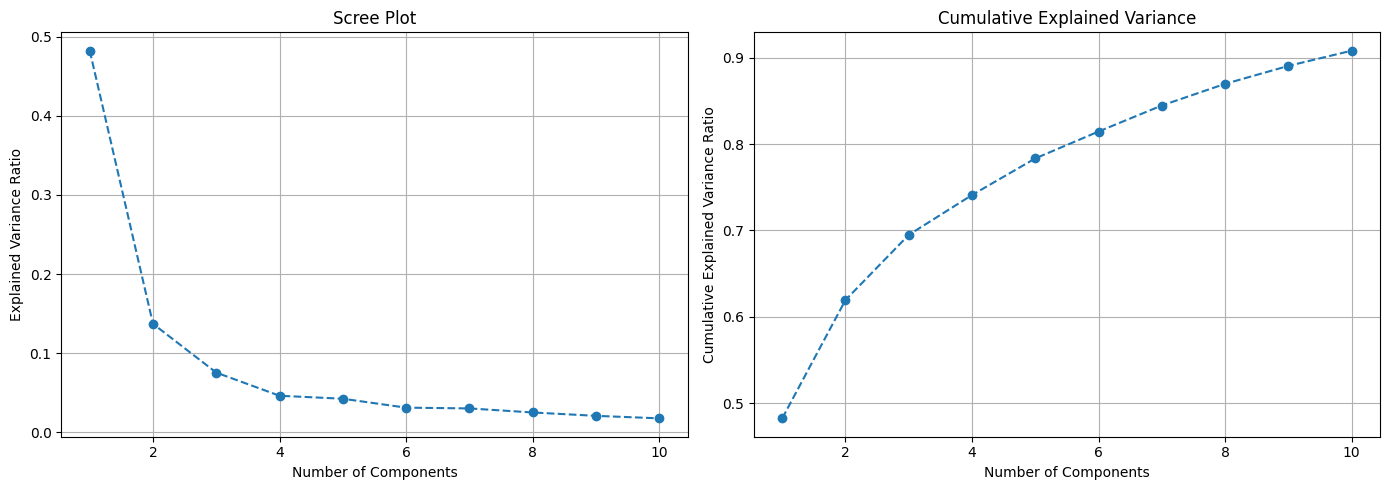

In [44]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)

plt.tight_layout()
plt.show()

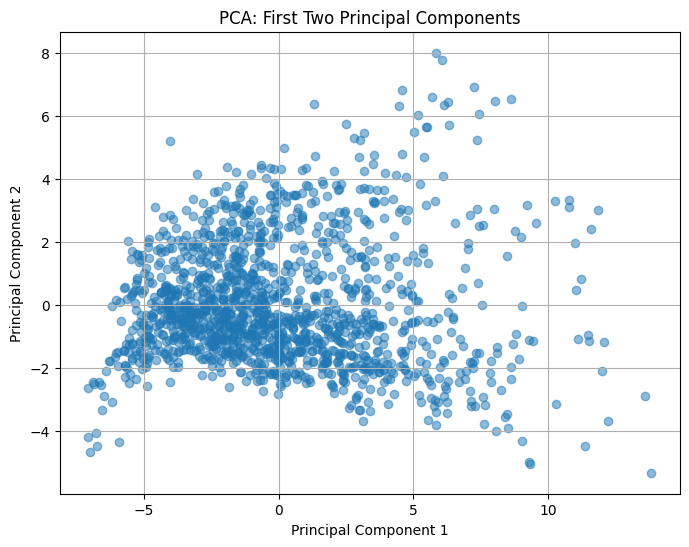

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(nba_pca[:, 0], nba_pca[:, 1], alpha=0.5)
plt.title('PCA: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

X = nba_pca
y = nba_data['Play']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1126, 10)
Shape of X_test: (282, 10)
Shape of y_train: (1126,)
Shape of y_test: (282,)


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9716
Precision: 0.7500
Recall: 0.7500
F1-score: 0.7500
